1

In [26]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne

In [43]:
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")
DATA_ROOT = PROJECT_ROOT / "data\ds005385"

subject = "sub-102"
condition = "EyesClosed"

edf_file = (
    DATA_ROOT
    / subject
    / "ses-1"
    / "eeg"
    / f"{subject}_ses-1_task-{condition}_acq-pre_eeg.edf"
)

print(edf_file)
print(edf_file.exists())

C:\Users\maria\Desktop\EEG-special-course\data\ds005385\sub-102\ses-1\eeg\sub-102_ses-1_task-EyesClosed_acq-pre_eeg.edf
True


2

In [44]:
raw = mne.io.read_raw_edf(edf_file, preload=True, verbose="ERROR")

print(raw)
print(raw.ch_names[:20])
print(raw.info["sfreq"])

<RawEDF | sub-102_ses-1_task-EyesClosed_acq-pre_eeg.edf, 65 x 191000 (191.0 s), ~94.8 MiB, data loaded>
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2']
1000.0


3

In [45]:
channel = "Oz"

if channel not in raw.ch_names:
    channel = "O1"

print("Using channel:", channel)

Using channel: Oz


4

In [47]:
def plot_time_series(raw_obj, channel="Oz", start=0, duration=10, title="EEG time series"):
    sfreq = raw_obj.info["sfreq"]

    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    data = raw_obj.copy().pick([channel]).get_data(
        start=start_sample,
        stop=stop_sample
    )[0]

    times = np.arange(len(data)) / sfreq + start

    plt.figure(figsize=(12, 4))
    plt.plot(times, data * 1e6)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.title(title)
    plt.show()

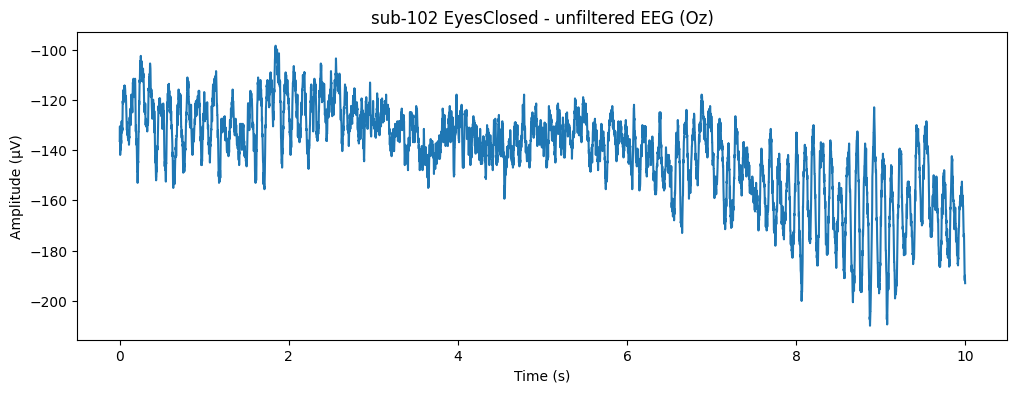

In [48]:
plot_time_series(
    raw,
    channel=channel,
    start=0,
    duration=10,
    title=f"{subject} {condition} - unfiltered EEG ({channel})"
)

5

In [49]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=1.0,
    h_freq=40.0,
    verbose="ERROR"
)

<RawEDF | sub-102_ses-1_task-EyesClosed_acq-pre_eeg.edf, 65 x 191000 (191.0 s), ~94.8 MiB, data loaded>

6

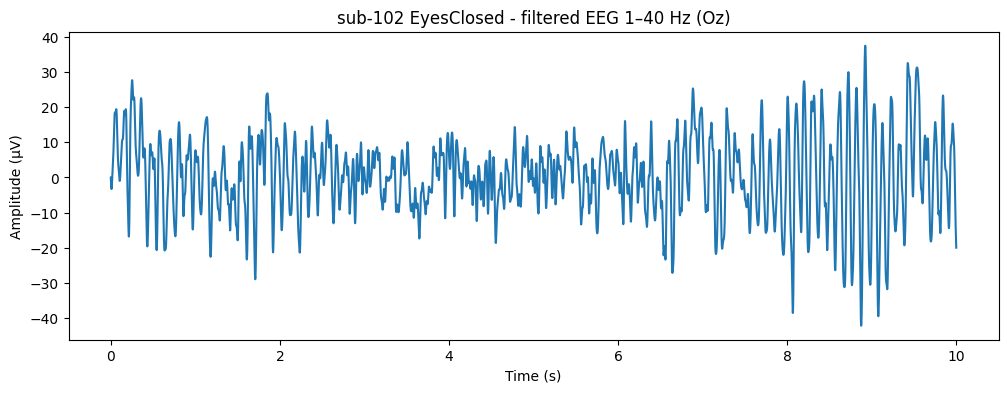

In [50]:
plot_time_series(
    raw_filtered,
    channel=channel,
    start=0,
    duration=10,
    title=f"{subject} {condition} - filtered EEG 1–40 Hz ({channel})"
)

7

In [51]:
def plot_raw_vs_filtered(raw_obj, filtered_obj, channel="Oz", start=0, duration=10):
    sfreq = raw_obj.info["sfreq"]

    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    raw_data = raw_obj.copy().pick([channel]).get_data(
        start=start_sample,
        stop=stop_sample
    )[0] * 1e6

    filt_data = filtered_obj.copy().pick([channel]).get_data(
        start=start_sample,
        stop=stop_sample
    )[0] * 1e6

    times = np.arange(len(raw_data)) / sfreq + start

    plt.figure(figsize=(12, 5))
    plt.plot(times, raw_data, label="Unfiltered", alpha=0.7)
    plt.plot(times, filt_data, label="Filtered 1–40 Hz", alpha=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.title(f"Raw vs filtered EEG - {channel}")
    plt.legend()
    plt.show()

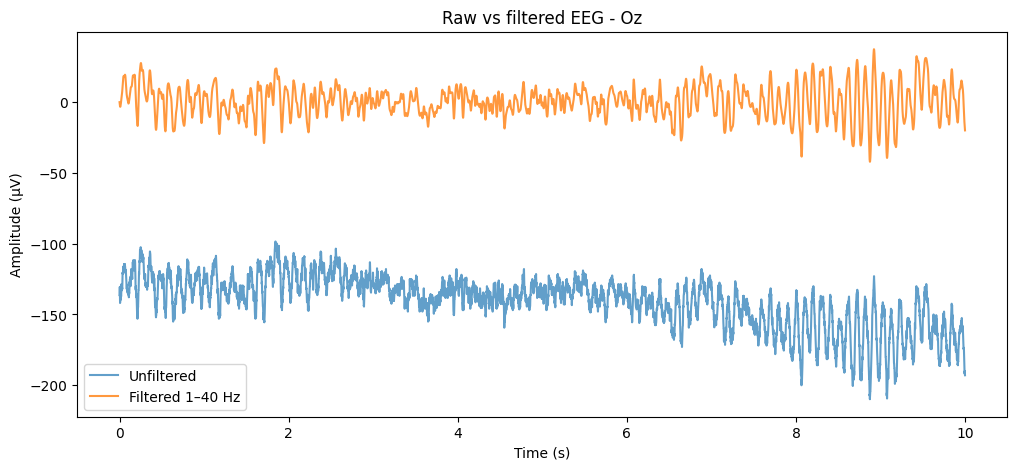

In [52]:
plot_raw_vs_filtered(
    raw,
    raw_filtered,
    channel=channel,
    start=0,
    duration=10
)

8

In [53]:
def compute_tfr_one_channel(
    raw_obj,
    channel="Oz",
    freqs=np.arange(2, 60, 1),
    epoch_length=8.0
):
    raw_ch = raw_obj.copy().pick([channel])

    epochs = mne.make_fixed_length_epochs(
        raw_ch,
        duration=epoch_length,
        overlap=0.0,
        preload=True,
        verbose="ERROR"
    )

    power = epochs.compute_tfr(
        method="morlet",
        freqs=freqs,
        n_cycles=3,
        average=True,
        return_itc=False,
        verbose="ERROR"
    )

    return power

In [54]:
power_raw = compute_tfr_one_channel(raw, channel=channel)
power_filtered = compute_tfr_one_channel(raw_filtered, channel=channel)

9

In [55]:
def plot_tfr_comparison(power_raw, power_filtered, subject, condition, channel="Oz"):
    data_raw = power_raw.data[0]
    data_filt = power_filtered.data[0]

    times = power_raw.times
    freqs = power_raw.freqs

    combined = np.concatenate([data_raw.ravel(), data_filt.ravel()])
    vmin = np.percentile(combined, 5)
    vmax = np.percentile(combined, 95)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    im0 = axes[0].imshow(
        data_raw,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
        vmin=vmin,
        vmax=vmax
    )
    axes[0].set_title("Unfiltered")
    axes[0].set_xlabel("Time within 4-s epoch (s)")
    axes[0].set_ylabel("Frequency (Hz)")

    im1 = axes[1].imshow(
        data_filt,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
        vmin=vmin,
        vmax=vmax
    )
    axes[1].set_title("Filtered 1–40 Hz")
    axes[1].set_xlabel("Time within 4-s epoch (s)")
    axes[1].set_ylabel("Frequency (Hz)")

    for ax in axes:
        ax.axhline(1, color="white", linestyle="--", linewidth=1)
        ax.axhline(40, color="white", linestyle="--", linewidth=1)
        ax.axhline(50, color="red", linestyle="--", linewidth=1)

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Power")

    fig.suptitle(
        f"{subject} {condition} - Spectrogram before and after filtering ({channel})",
        fontsize=14
    )

    plt.show()

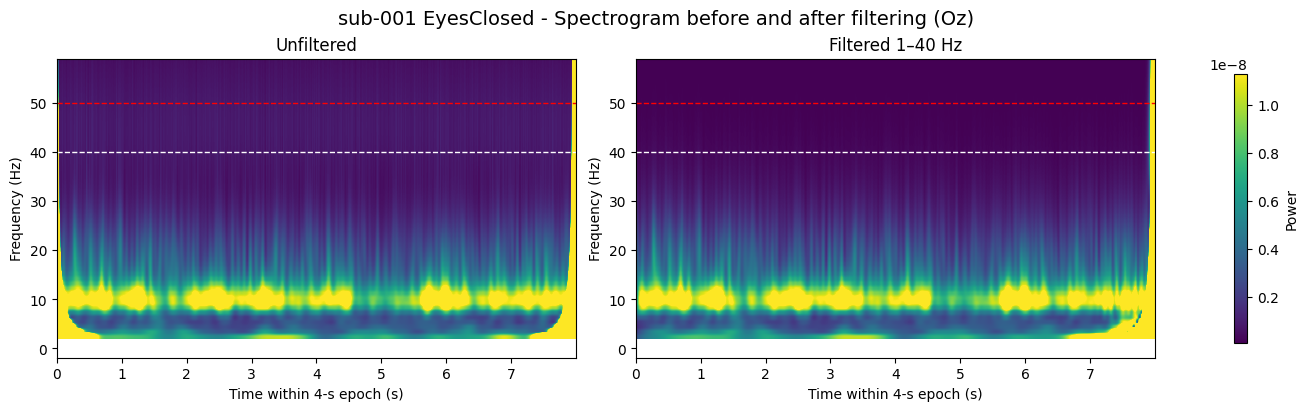

In [41]:
plot_tfr_comparison(
    power_raw,
    power_filtered,
    subject=subject,
    condition=condition,
    channel=channel
)

10

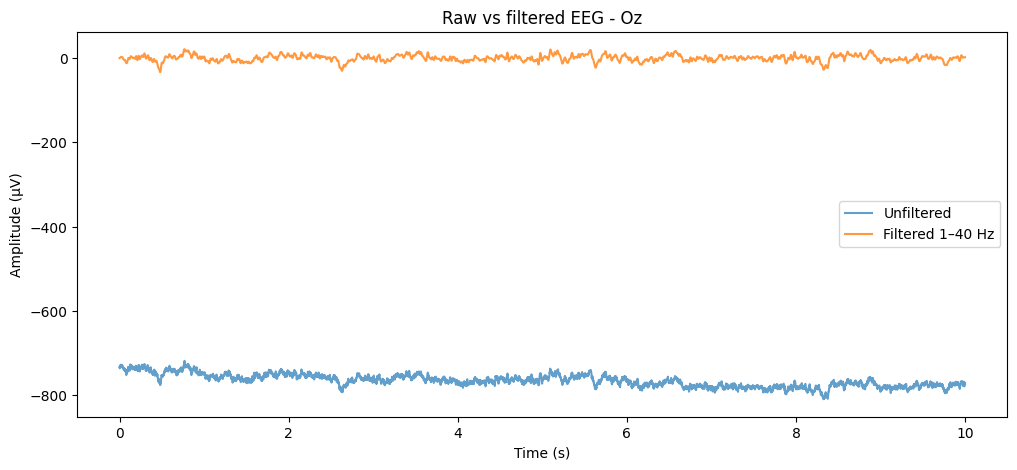

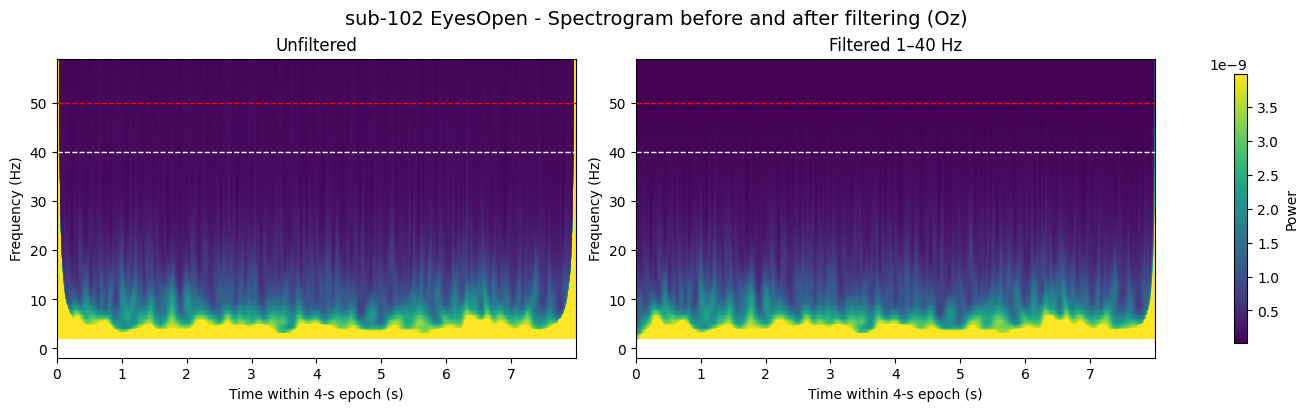

In [56]:
condition = "EyesOpen"

edf_file = (
    DATA_ROOT
    / subject
    / "ses-1"
    / "eeg"
    / f"{subject}_ses-1_task-{condition}_acq-pre_eeg.edf"
)

raw = mne.io.read_raw_edf(edf_file, preload=True, verbose="ERROR")
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0, verbose="ERROR")

plot_raw_vs_filtered(raw, raw_filtered, channel=channel, start=0, duration=10)

power_raw = compute_tfr_one_channel(raw, channel=channel)
power_filtered = compute_tfr_one_channel(raw_filtered, channel=channel)

plot_tfr_comparison(
    power_raw,
    power_filtered,
    subject=subject,
    condition=condition,
    channel=channel
)

## Power spectral density before and after filtering

To better visualize the frequency content of the EEG signal, I plotted the power spectral density (PSD) before and after filtering. The PSD shows how much power is present at each frequency. This is useful for checking whether slow drift, 50 Hz line noise, and high-frequency noise are reduced by the 1–40 Hz band-pass filter.

In [57]:
def plot_psd_before_after(raw_obj, filtered_obj, channel="Oz", fmin=0, fmax=70):
    raw_ch = raw_obj.copy().pick([channel])
    filt_ch = filtered_obj.copy().pick([channel])

    psd_raw = raw_ch.compute_psd(
        method="welch",
        fmin=fmin,
        fmax=fmax,
        verbose="ERROR"
    )

    psd_filt = filt_ch.compute_psd(
        method="welch",
        fmin=fmin,
        fmax=fmax,
        verbose="ERROR"
    )

    raw_power, freqs = psd_raw.get_data(return_freqs=True)
    filt_power, _ = psd_filt.get_data(return_freqs=True)

    raw_power_db = 10 * np.log10(raw_power[0])
    filt_power_db = 10 * np.log10(filt_power[0])

    plt.figure(figsize=(10, 5))

    plt.plot(freqs, raw_power_db, label="Unfiltered")
    plt.plot(freqs, filt_power_db, label="Filtered 1–40 Hz")

    plt.axvline(1, linestyle="--", label="1 Hz high-pass cutoff")
    plt.axvline(40, linestyle="--", label="40 Hz low-pass cutoff")
    plt.axvline(50, linestyle="--", label="50 Hz line noise")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (dB)")
    plt.title(f"PSD before and after filtering - {subject} {condition} ({channel})")
    plt.legend()
    plt.show()

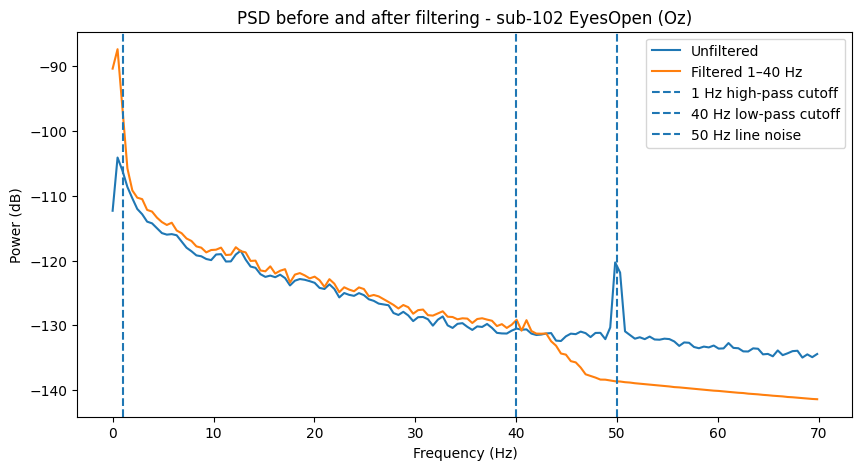

In [58]:
plot_psd_before_after(
    raw,
    raw_filtered,
    channel=channel,
    fmin=0,
    fmax=70
)

In [59]:
def plot_raw_vs_filtered_centered(raw_obj, filtered_obj, channel="Oz", start=0, duration=10):
    sfreq = raw_obj.info["sfreq"]

    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    raw_data = raw_obj.copy().pick([channel]).get_data(
        start=start_sample,
        stop=stop_sample
    )[0] * 1e6

    filt_data = filtered_obj.copy().pick([channel]).get_data(
        start=start_sample,
        stop=stop_sample
    )[0] * 1e6

    # Remove the mean only for visualization
    raw_data = raw_data - raw_data.mean()
    filt_data = filt_data - filt_data.mean()

    times = np.arange(len(raw_data)) / sfreq + start

    plt.figure(figsize=(12, 5))
    plt.plot(times, raw_data, label="Unfiltered, mean removed", alpha=0.7)
    plt.plot(times, filt_data, label="Filtered 1–40 Hz, mean removed", alpha=0.8)

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV, centered)")
    plt.title(f"Raw vs filtered EEG - centered view - {channel}")
    plt.legend()
    plt.show()

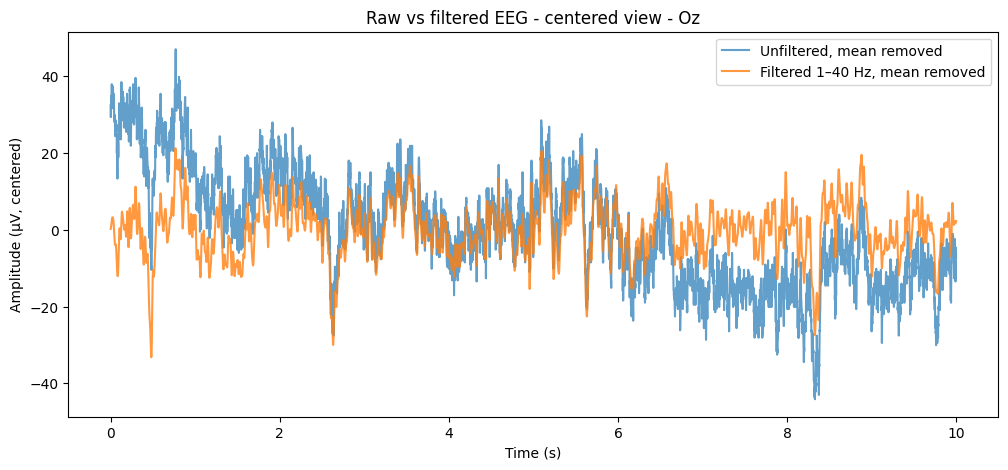

In [60]:
plot_raw_vs_filtered_centered(
    raw,
    raw_filtered,
    channel=channel,
    start=0,
    duration=10
)